# Leading Edge Reconstruction from Sparse PMT Samples

**Platforma:** Xilinx ZCU106 / PYNQ  
**Metody interpolacji:** Linear (LIN) | Exponential (EXP) | Logarithmic (LOG)  
**Format danych:** Q16.16 fixed-point  
**Wejście:** 3 próbki (t₁,A₁), (t₂,A₂), (t₃,A₃) ze zbocza narastającego PMT  
**Wyjście:** t₀_est – czas leading edge [ns], Amax_est – amplituda maksymalna  

---

## 1. Importy i załadowanie overlay (bitstream)

In [ ]:
import zipfile, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pynq import Overlay

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'legend.fontsize':   9,
    'figure.dpi':        110,
})

XSA_FILE = 'DB_leading_edge_axi_lite.xsa'
hwh_dst  = XSA_FILE.replace('.xsa', '.hwh')

if not os.path.exists(hwh_dst):
    with zipfile.ZipFile(XSA_FILE, 'r') as z:
        hwh_inside = [f for f in z.namelist() if f.endswith('.hwh')][0]
        with z.open(hwh_inside) as src, open(hwh_dst, 'wb') as dst:
            dst.write(src.read())
    print(f'Wyodrębniono: {hwh_dst}')
else:
    print(f'{hwh_dst} już istnieje.')

ol = Overlay(XSA_FILE)
ip = ol.myip_leading_edge_ax_0
print(f'Overlay OK | IP dict: {list(ol.ip_dict.keys())}')
print(f'Adres bazowy IP: 0x{ip.mmio.base_addr:08X}')

DB_leading_edge_axi_lite.hwh już istnieje.
Overlay OK | IP dict: ['myip_leading_edge_ax_0', 'zynq_ultra_ps_e_0']
Adres bazowy IP: 0xA0000000


## 2. Mapa rejestrów AXI-Lite

| Offset | Nazwa    | Kier. | Opis                                  |
|--------|----------|-------|---------------------------------------|
| 0x00   | CTRL     | W     | [0]=start, [2:1]=mode_sel (0/1/2)     |
| 0x04   | STATUS   | R     | [0]=done, [1]=valid, [2]=overflow     |
| 0x08   | T1       | W     | Czas próbki 1 [ns] – Q16.16          |
| 0x0C   | A1       | W     | Amplituda próbki 1 – Q16.16          |
| 0x10   | T2       | W     | Czas próbki 2 [ns] – Q16.16          |
| 0x14   | A2       | W     | Amplituda próbki 2 – Q16.16          |
| 0x18   | T3       | W     | Czas próbki 3 [ns] – Q16.16          |
| 0x1C   | A3       | W     | Amplituda próbki 3 – Q16.16          |
| 0x20   | THRESH   | W     | Próg napięciowy – Q16.16             |
| 0x24   | T0_EST   | R     | **Wynik:** t₀ leading edge – Q16.16  |
| 0x28   | AMAX_EST | R     | **Wynik:** amplituda maks. – Q16.16  |
| 0x2C   | EVENT_ID | R     | Numer zdarzenia (uint32)              |

> **Tryby (mode_sel):** `0` = LIN (liniowa) · `1` = EXP (eksponencjalna) · `2` = LOG (logarytmiczna)

## 3. Definicje rejestrów i konwersja Q16.16

In [ ]:
# ── Offsety rejestrów ────────────────────────────────────────────
REG_CTRL, REG_STATUS             = 0x00, 0x04
REG_T1,   REG_A1                 = 0x08, 0x0C
REG_T2,   REG_A2                 = 0x10, 0x14
REG_T3,   REG_A3                 = 0x18, 0x1C
REG_THRESH, REG_T0_EST           = 0x20, 0x24
REG_AMAX_EST, REG_EVENT_ID       = 0x28, 0x2C

MODE_LIN, MODE_EXP, MODE_LOG     = 0, 1, 2
MODES      = [MODE_LIN, MODE_EXP, MODE_LOG]
MODE_NAMES = {MODE_LIN: 'LIN', MODE_EXP: 'EXP', MODE_LOG: 'LOG'}
COLORS     = {'LIN': '#E15759', 'EXP': '#4E79A7', 'LOG': '#59A14F'}

# ── Konwersja Q16.16 ──────────────────────────────────────────────
def to_q16(v):
    """float → Q16.16 unsigned int32"""
    return int(round(v * 65536.0)) & 0xFFFF_FFFF

def from_q16(v):
    """Q16.16 uint32 → float (ze znakiem)"""
    v = int(v) & 0xFFFF_FFFF
    if v & 0x8000_0000:
        v -= 0x1_0000_0000
    return v / 65536.0

ip_write = lambda offset, val: ip.write(offset, int(val) & 0xFFFF_FFFF)
ip_read  = lambda offset: ip.read(offset)
print('Inicjalizacja OK.')

Inicjalizacja OK.


## 4. Test komunikacji AXI-Lite (write → read-back)

In [ ]:
TESTS = [
    (REG_T1,   0x1234_5678,   'T1  raw'),
    (REG_T2,   0xDEAD_BEEF,   'T2  raw'),
    (REG_A1,   to_q16(1.25),  'A1 = 1.25'),
    (REG_A2,   to_q16(3.75),  'A2 = 3.75'),
    (REG_THRESH, to_q16(0.3), 'THRESH = 0.3'),
]
all_ok = True
for offset, val, name in TESTS:
    ip_write(offset, val)
    rb  = ip_read(offset)
    ok  = rb == (val & 0xFFFF_FFFF)
    all_ok &= ok
    mark = '✓ OK  ' if ok else '✗ FAIL'
    print(f'  [{mark}]  {name:18s}  write=0x{val:08X}  read=0x{rb:08X}')
print()
print('Komunikacja AXI:', 'PASS ✓' if all_ok else 'FAIL ✗')

  [✓ OK  ]  T1  raw             write=0x12345678  read=0x12345678
  [✓ OK  ]  T2  raw             write=0xDEADBEEF  read=0xDEADBEEF
  [✓ OK  ]  A1 = 1.25           write=0x00014000  read=0x00014000
  [✓ OK  ]  A2 = 3.75           write=0x0003C000  read=0x0003C000
  [✓ OK  ]  THRESH = 0.3        write=0x00004CCD  read=0x00004CCD

Komunikacja AXI: PASS ✓


## 5. Funkcja sterująca koprocesorem FPGA

In [ ]:
def fpga_compute(t1, a1, t2, a2, t3, a3, threshold, mode, timeout=50_000):
    """
    Uruchamia koprocesor FPGA (jeden tryb) dla jednego zdarzenia PMT.

    Parametry
    ---------
    t1,a1,t2,a2,t3,a3 : float – próbki (czas [ns], amplituda [V])
    threshold          : float – próg napięciowy [V]
    mode               : int   – 0=LIN, 1=EXP, 2=LOG
    timeout            : int   – maks. iteracji polling

    Zwraca
    ------
    (t0_est, amax_est, overflow)  lub  (None, None, None) przy timeout
    """
    # 1. Reset CTRL
    ip_write(REG_CTRL, 0)
    # 2. Zapisz dane wejściowe (Q16.16)
    ip_write(REG_T1,     to_q16(t1))
    ip_write(REG_A1,     to_q16(a1))
    ip_write(REG_T2,     to_q16(t2))
    ip_write(REG_A2,     to_q16(a2))
    ip_write(REG_T3,     to_q16(t3))
    ip_write(REG_A3,     to_q16(a3))
    ip_write(REG_THRESH, to_q16(threshold))
    # 3. START + mode_sel
    ip_write(REG_CTRL, (mode << 1) | 1)
    # 4. Polling bitu DONE
    for _ in range(timeout):
        if ip_read(REG_STATUS) & 0x1:
            break
    else:
        print(f'[TIMEOUT] mode={MODE_NAMES[mode]}')
        ip_write(REG_CTRL, 0)
        return None, None, None
    # 5. Odczyt wyników
    t0_est   = from_q16(ip_read(REG_T0_EST))
    amax_est = from_q16(ip_read(REG_AMAX_EST))
    overflow = bool((ip_read(REG_STATUS) >> 2) & 1)
    ip_write(REG_CTRL, 0)   # opuść START
    return t0_est, amax_est, overflow

print('fpga_compute() gotowa.')

fpga_compute() gotowa.


## 6. Golden model Python (referencja)

Trzy metody interpolacji zaimplementowane w czystym Pythonie.
Służą jako wzorzec do porównania z wynikami koprocesora FPGA.

| Metoda | Model matematyczny |
|--------|-------------------|
| LIN    | interpolacja liniowa A(t) między (t₁,A₁) i (t₂,A₂) |
| EXP    | A(t) = A₀·exp(b·t), parametry b i A₀ z 2 próbek |
| LOG    | interpolacja liniowa w przestrzeni ln(A) vs t |

In [ ]:
def py_linear(t1, a1, t2, a2, thr):
    """t0 przez interpolację liniową."""
    dA = a2 - a1
    if dA == 0: return None
    return t1 + (thr - a1) * (t2 - t1) / dA

def py_exponential(t1, a1, t2, a2, thr):
    """t0 przez model A=A0*exp(b*t) z 2 próbek."""
    if a1 <= 0 or a2 <= 0: return None
    dt = t2 - t1
    if dt == 0: return None
    b   = (np.log(a2) - np.log(a1)) / dt
    if b == 0: return None
    lnA = np.log(a1) - b * t1
    return (np.log(thr) - lnA) / b

def py_logarithmic(t1, a1, t2, a2, t3, a3, thr):
    """t0 przez interpolację liniową w przestrzeni log(A) vs t."""
    if a1 <= 0 or a2 <= 0 or a3 <= 0: return None
    l1, l2 = np.log(a1), np.log(a2)
    dl = l2 - l1
    if dl == 0: return None
    return t1 + (np.log(thr) - l1) * (t2 - t1) / dl

PY_FN = {
    MODE_LIN: lambda r, th: py_linear(r['t1'], r['A1'], r['t2'], r['A2'], th),
    MODE_EXP: lambda r, th: py_exponential(r['t1'], r['A1'], r['t2'], r['A2'], th),
    MODE_LOG: lambda r, th: py_logarithmic(r['t1'], r['A1'], r['t2'], r['A2'],
                                            r['t3'], r['A3'], th),
}
print('Golden model Python załadowany.')

Golden model Python załadowany.


## 7. Wczytanie danych testowych (CSV)

In [ ]:
df = pd.read_csv('example_samples.csv')
THRESHOLD = 0.3   # próg napięciowy [V]
print(f'Wczytano {len(df)} zdarzeń. Kolumny: {list(df.columns)}')
df.head(3)

Wczytano 20 zdarzeń. Kolumny: ['event_id', 't1', 'A1', 't2', 'A2', 't3', 'A3', 'true_t0', 'true_amax', 'sigma_ns', 'tau_ns', 'threshold', 'charge', 'true_t_leading', 'true_t_trailing', 'true_tot']


,event_id,t1,A1,t2,A2,t3,A3,true_t0,true_amax,sigma_ns,tau_ns,threshold,charge,true_t_leading,true_t_trailing,true_tot
0,0,12.639493,0.242324,17.121957,1.106515,18.823771,1.397267,20.266829,1.499501,4.0,8.0,0.3,1.499501,13.091081,34.139669,21.048587
1,1,14.808737,0.318532,17.186481,0.680438,19.243297,0.977680,21.035520,1.070234,4.0,8.0,0.3,1.070234,14.655928,32.210319,17.554391
2,2,14.949275,1.051854,18.598672,3.691896,20.420526,5.054359,22.392033,5.722857,4.0,8.0,0.3,5.722857,12.678634,46.979561,34.300927


## 8. Obliczenia: FPGA vs Python (golden model)

In [ ]:
records = []

for _, row in df.iterrows():
    ev = int(row['event_id'])
    t1, a1 = row['t1'], row['A1']
    t2, a2 = row['t2'], row['A2']
    t3, a3 = row['t3'], row['A3']
    true_t0 = row['true_t_leading']

    for mode in MODES:
        mn    = MODE_NAMES[mode]
        py_t0 = PY_FN[mode](row, THRESHOLD)

        t_start = time.perf_counter()
        fpga_t0, fpga_amax, ovf = fpga_compute(
            t1, a1, t2, a2, t3, a3, THRESHOLD, mode)
        elapsed = time.perf_counter() - t_start

        err_py   = abs(fpga_t0 - py_t0)   if fpga_t0 is not None and py_t0 is not None else None
        err_true = abs(fpga_t0 - true_t0) if fpga_t0 is not None else None

        records.append(dict(
            event_id      = ev,
            mode          = mn,
            fpga_t0       = fpga_t0,
            python_t0     = py_t0,
            true_t0       = true_t0,
            err_vs_python = err_py,
            err_vs_true   = err_true,
            overflow      = ovf,
            fpga_time_us  = elapsed * 1e6,
        ))

res = pd.DataFrame(records)
print(f'Obliczono {len(res)} wyników ({len(df)} zdarzeń × {len(MODES)} metody).')

Obliczono 60 wyników (20 zdarzeń × 3 metody).


## 9. Tabela wyników

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)
cols = ['event_id', 'mode', 'fpga_t0', 'python_t0', 'true_t0',
        'err_vs_python', 'err_vs_true', 'overflow']
display(res[cols])

,event_id,mode,fpga_t0,python_t0,true_t0,err_vs_python,err_vs_true,overflow
0,0,LIN,12.9392,12.9387,13.0911,0.0005,0.1519,False
1,0,EXP,13.2637,13.2697,13.0911,0.0060,0.1726,False
2,0,LOG,13.2857,13.2697,13.0911,0.0160,0.1946,False
3,1,LIN,14.6880,14.6870,14.6559,0.0010,0.0321,False
4,1,EXP,14.6290,14.6210,14.6559,0.0080,0.0269,False
5,1,LOG,14.6058,14.6210,14.6559,0.0152,0.0501,False
6,2,LIN,13.9109,13.9100,12.6786,0.0009,1.2323,False
7,2,EXP,11.3120,11.3030,12.6786,0.0090,1.3666,False
8,2,LOG,11.2898,11.3030,12.6786,0.0132,1.3888,False
9,3,LIN,10.7379,10.7376,10.7213,0.0003,0.0166,False


## 10. Statystyki błędów

In [ ]:
sep = '=' * 62
print(sep)
print(f'  {"Metoda":<6}  {"mean |Δt₀|":>14}  {"max |Δt₀|":>13}  {"std":>10}')
print(sep)
print('FPGA vs Python (golden model)')
for mode in MODES:
    mn  = MODE_NAMES[mode]
    sub = res[res['mode'] == mn]['err_vs_python'].dropna()
    print(f'  {mn:<6}  {sub.mean():>12.4f} ns  {sub.max():>11.4f} ns  {sub.std():>8.4f} ns')
print(sep)
print('FPGA vs true_t_leading')
for mode in MODES:
    mn  = MODE_NAMES[mode]
    sub = res[res['mode'] == mn]['err_vs_true'].dropna()
    print(f'  {mn:<6}  {sub.mean():>12.4f} ns  {sub.max():>11.4f} ns  {sub.std():>8.4f} ns')
print(sep)
print(f'  Overflow: {res["overflow"].sum()}/{len(res)}')

  Metoda      mean |Δt₀|      max |Δt₀|         std
FPGA vs Python (golden model)
  LIN           0.0006 ns       0.0010 ns    0.0003 ns
  EXP           0.0061 ns       0.0090 ns    0.0021 ns
  LOG           0.0120 ns       0.0160 ns    0.0029 ns
FPGA vs true_t_leading
  LIN           0.5208 ns       1.5374 ns    0.4655 ns
  EXP           0.5134 ns       1.4649 ns    0.5072 ns
  LOG           0.5315 ns       1.4886 ns    0.5081 ns
  Overflow: 0/60


---
## 11. Wykresy porównawcze

> **Legenda wspólna dla wykresów:**  
> 🔴 LIN – interpolacja liniowa &nbsp;|&nbsp;
> 🔵 EXP – model eksponencjalny &nbsp;|&nbsp;
> 🟢 LOG – interpolacja logarytmiczna

### 11.1 FPGA t₀ vs Python t₀ – scatter (każda metoda osobno)

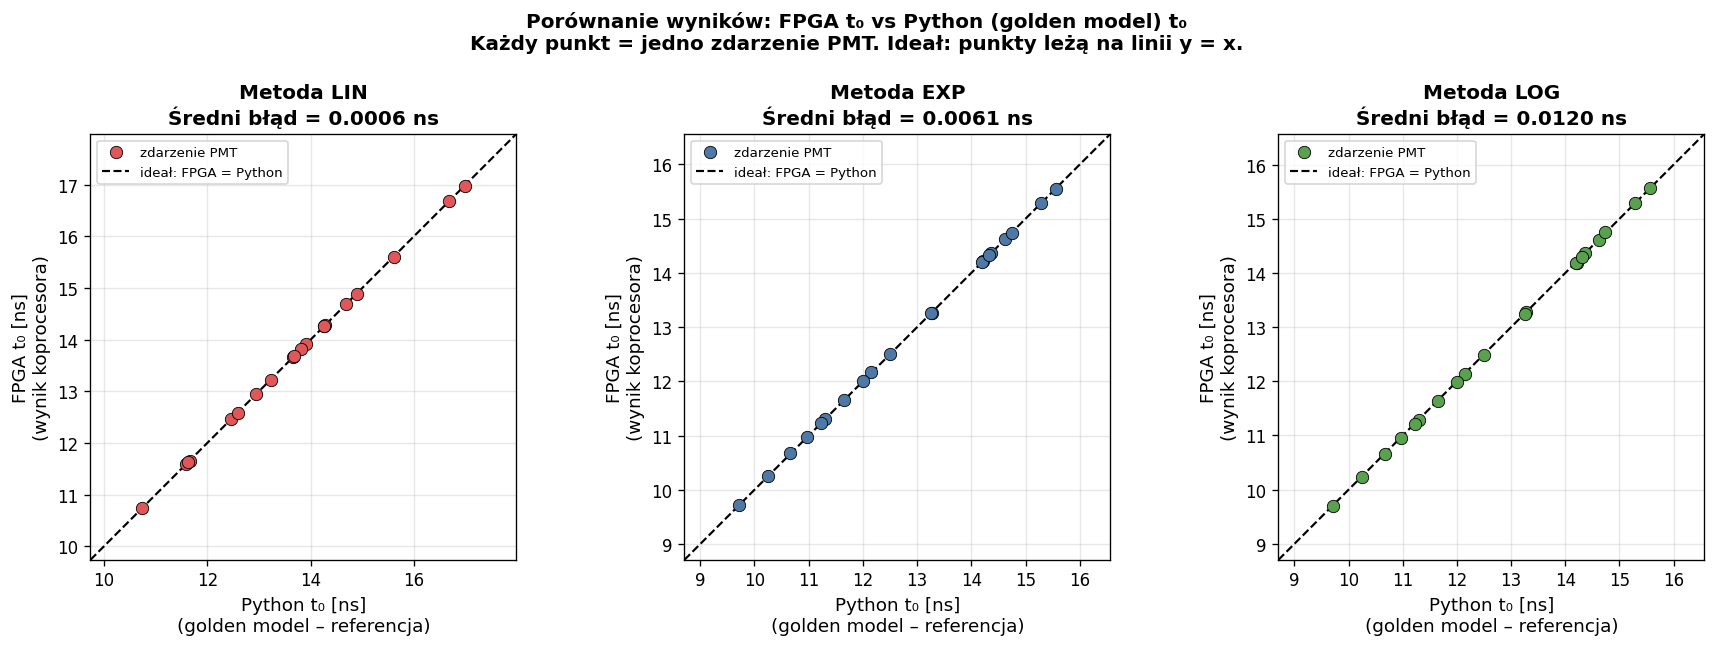

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Porównanie wyników: FPGA t₀  vs  Python (golden model) t₀\n'
             'Każdy punkt = jedno zdarzenie PMT. Ideał: punkty leżą na linii y = x.',
             fontsize=12, fontweight='bold', y=1.03)

for ax, mode in zip(axes, MODES):
    mn   = MODE_NAMES[mode]
    sub  = res[res['mode'] == mn].dropna(subset=['fpga_t0', 'python_t0'])
    py_v = sub['python_t0'].values
    fp_v = sub['fpga_t0'].values
    lo   = min(py_v.min(), fp_v.min()) - 1
    hi   = max(py_v.max(), fp_v.max()) + 1

    ax.scatter(py_v, fp_v, s=55, color=COLORS[mn],
               edgecolors='black', linewidth=0.5, zorder=3,
               label='zdarzenie PMT')
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.3, label='ideał: FPGA = Python')

    err_mean = np.mean(np.abs(fp_v - py_v))
    ax.set_xlabel('Python t₀  [ns]\n(golden model – referencja)', fontsize=10)
    ax.set_ylabel('FPGA t₀  [ns]\n(wynik koprocesora)',          fontsize=10)
    ax.set_title(f'Metoda {mn}\n'
                 r'Średni błąd $\bar{|\Delta t_0|}$' + f' = {err_mean:.2f} ns',
                 fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('plot1_scatter_fpga_vs_python.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.2 Błąd |FPGA − Python| dla każdego zdarzenia (zgrupowane słupki)

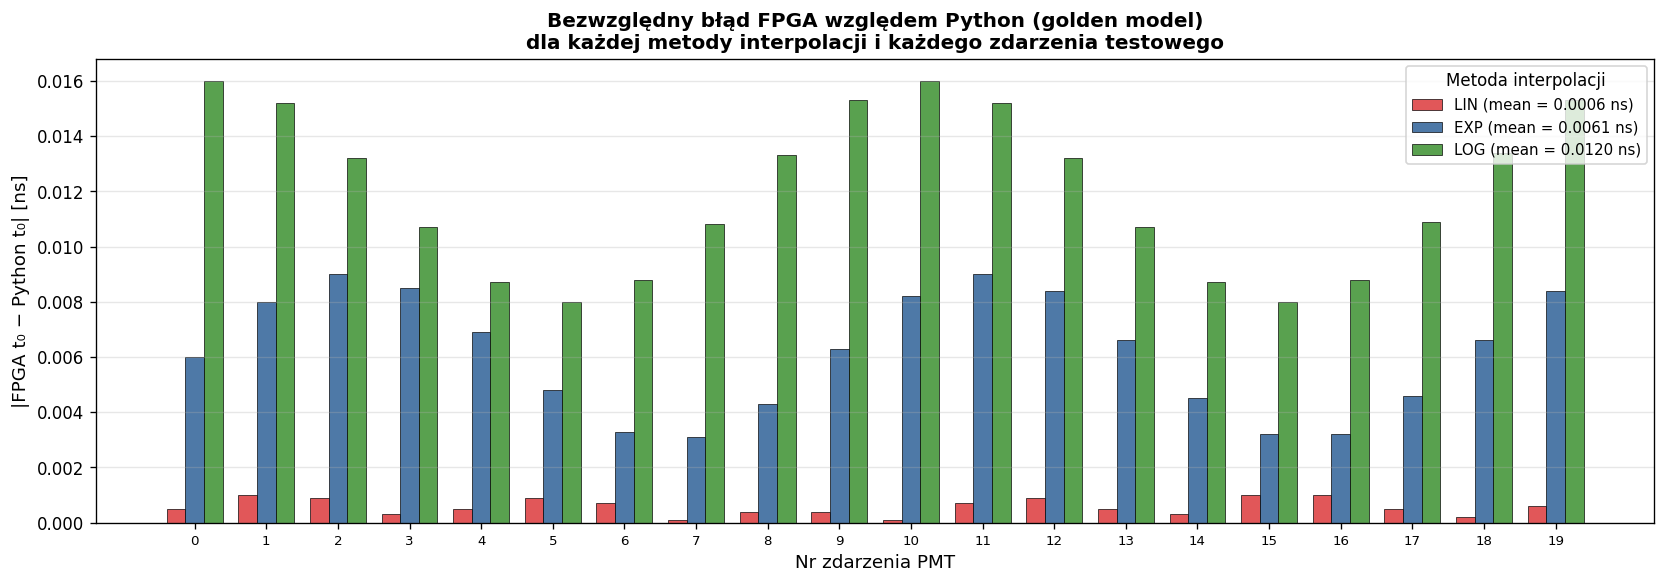

In [ ]:
err_dict = {
    mn: res[res['mode'] == mn]['err_vs_python'].values
    for mn in [MODE_NAMES[m] for m in MODES]
}
N = len(df)
x = np.arange(N)
w = 0.26

fig, ax = plt.subplots(figsize=(14, 5))
for i, mn in enumerate([MODE_NAMES[m] for m in MODES]):
    ax.bar(x + (i-1)*w, err_dict[mn], width=w,
           color=COLORS[mn], edgecolor='black', linewidth=0.4,
           label=f'{mn}  (mean = {np.mean(err_dict[mn]):.2f} ns)')

ax.set_xlabel('Nr zdarzenia PMT', fontsize=11)
ax.set_ylabel('|FPGA t₀  −  Python t₀|  [ns]\n(mniejszy = lepszy)', fontsize=11)
ax.set_title('Bezwzględny błąd FPGA względem Python (golden model)\n'
             'dla każdej metody interpolacji i każdego zdarzenia testowego',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=8)
ax.legend(title='Metoda interpolacji', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_error_per_event.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.3 Histogram błędów: rozkład |FPGA − Python|

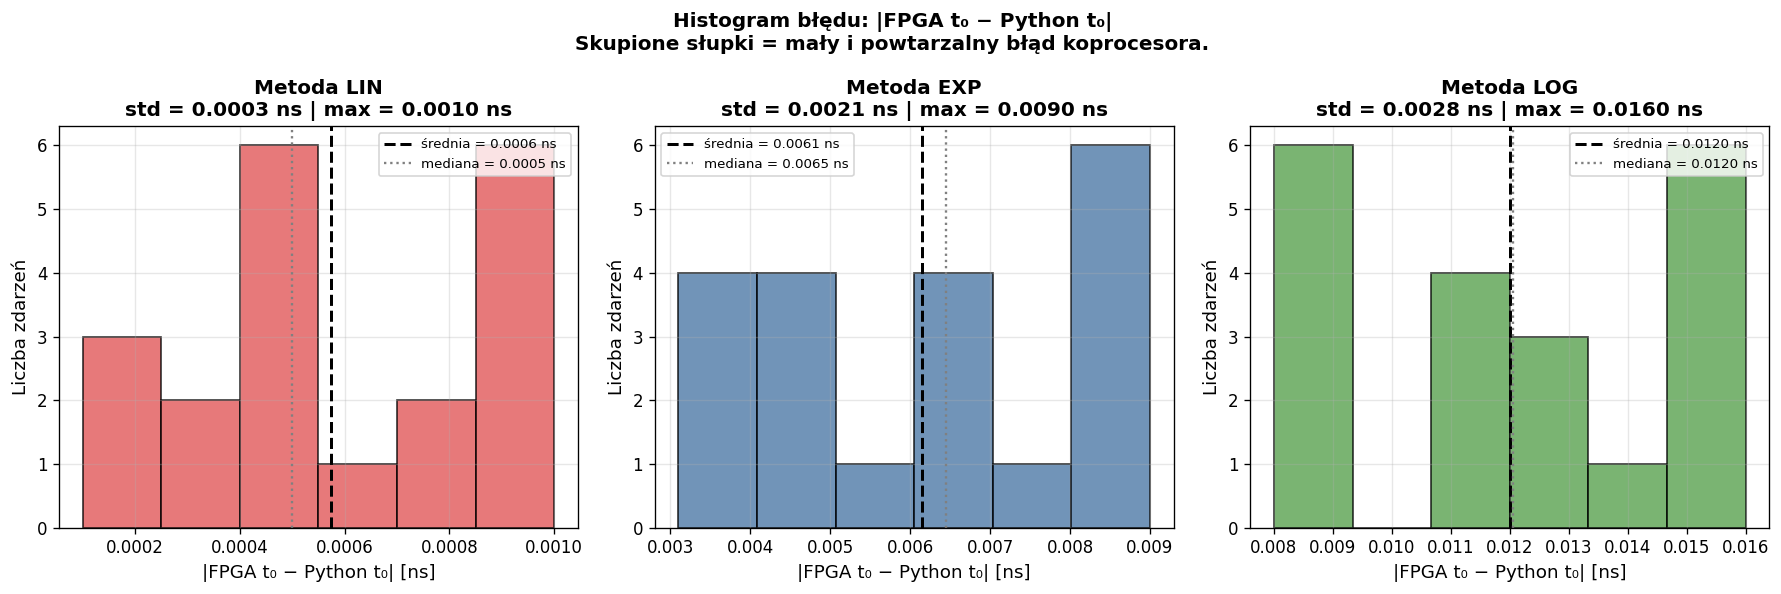

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Histogram błędu: |FPGA t₀  −  Python t₀|\n'
             'Skupione słupki = mały i powtarzalny błąd koprocesora.',
             fontsize=12, fontweight='bold')

for ax, mode in zip(axes, MODES):
    mn  = MODE_NAMES[mode]
    e   = res[res['mode'] == mn]['err_vs_python'].dropna().values
    ax.hist(e, bins=min(10, max(5, len(e)//3)),
            color=COLORS[mn], edgecolor='black', alpha=0.80)
    ax.axvline(e.mean(),    color='black', lw=1.8, ls='--',
               label=f'średnia = {e.mean():.2f} ns')
    ax.axvline(np.median(e), color='gray', lw=1.4, ls=':',
               label=f'mediana = {np.median(e):.2f} ns')
    ax.set_xlabel('|FPGA t₀  −  Python t₀|  [ns]', fontsize=10)
    ax.set_ylabel('Liczba zdarzeń',                  fontsize=10)
    ax.set_title(f'Metoda {mn}\nstd = {e.std():.3f} ns  |  max = {e.max():.2f} ns',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_histogram_errors.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.4 Rekonstrukcja t₀: timeline FPGA vs Python vs true

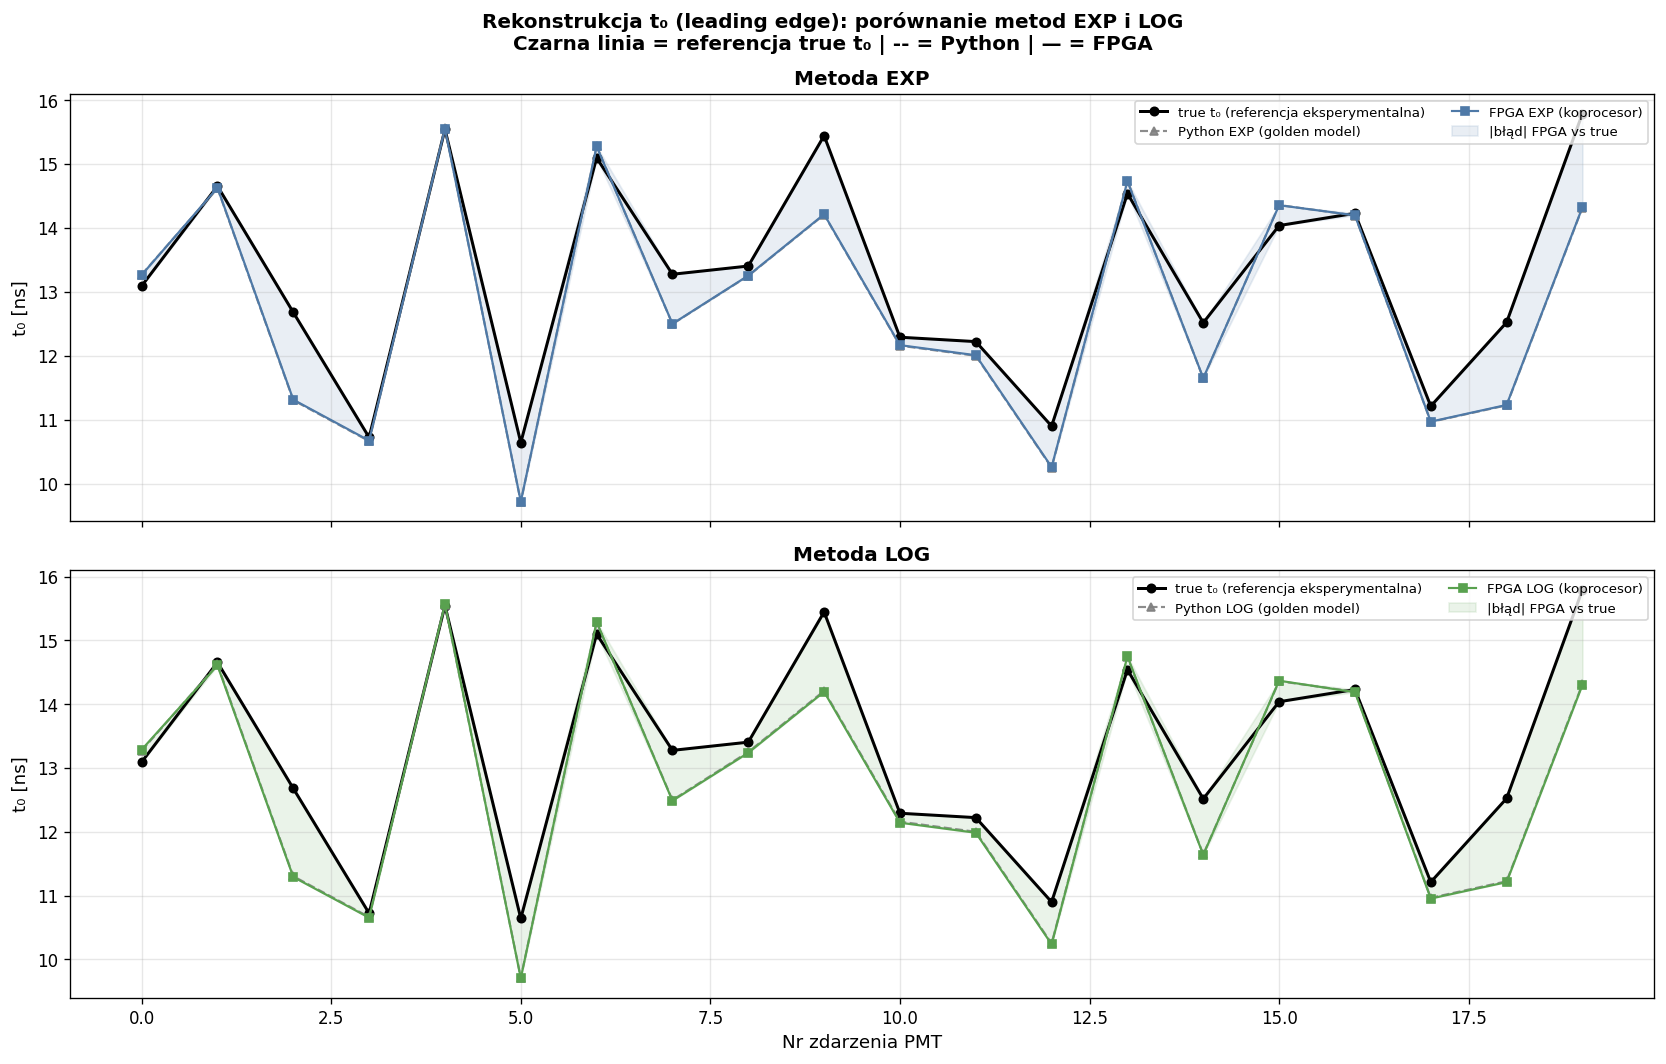

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Rekonstrukcja t₀ (leading edge): porównanie metod EXP i LOG\n'
             'Czarna linia = referencja true t₀ | -- = Python | — = FPGA',
             fontsize=12, fontweight='bold')

events_arr = res[res['mode']=='EXP']['event_id'].values

for ax, mn in zip(axes, ['EXP', 'LOG']):
    sub_py   = res[res['mode'] == mn]['python_t0'].values
    sub_fpga = res[res['mode'] == mn]['fpga_t0'].values
    sub_true = res[res['mode'] == mn]['true_t0'].values

    ax.plot(events_arr, sub_true,  'k-o',  ms=5, lw=1.8,
            label='true t₀  (referencja eksperymentalna)')
    ax.plot(events_arr, sub_py,    '--^',  ms=5, lw=1.3,
            color='gray', alpha=0.9,
            label=f'Python {mn}  (golden model)')
    ax.plot(events_arr, sub_fpga,  '-s',   ms=5, lw=1.3,
            color=COLORS[mn],
            label=f'FPGA {mn}  (koprocesor)')
    ax.fill_between(events_arr,
                    np.minimum(sub_true, sub_fpga),
                    np.maximum(sub_true, sub_fpga),
                    alpha=0.12, color=COLORS[mn],
                    label='|błąd| FPGA vs true')
    ax.set_ylabel('t₀  [ns]', fontsize=11)
    ax.set_title(f'Metoda {mn}', fontsize=11)
    ax.legend(loc='upper right', ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Nr zdarzenia PMT', fontsize=11)
plt.tight_layout()
plt.savefig('plot4_t0_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

### 11.5 Wizualizacja sygnału PMT – kształt impulsu i rekonstrukcja t₀

Przykładowe zdarzenie: kształt impulsu PMT (model Gaussa + ogon eksponencjalny),
trzy próbki użyte do rekonstrukcji oraz wyznaczone wartości t₀ dla każdej metody.

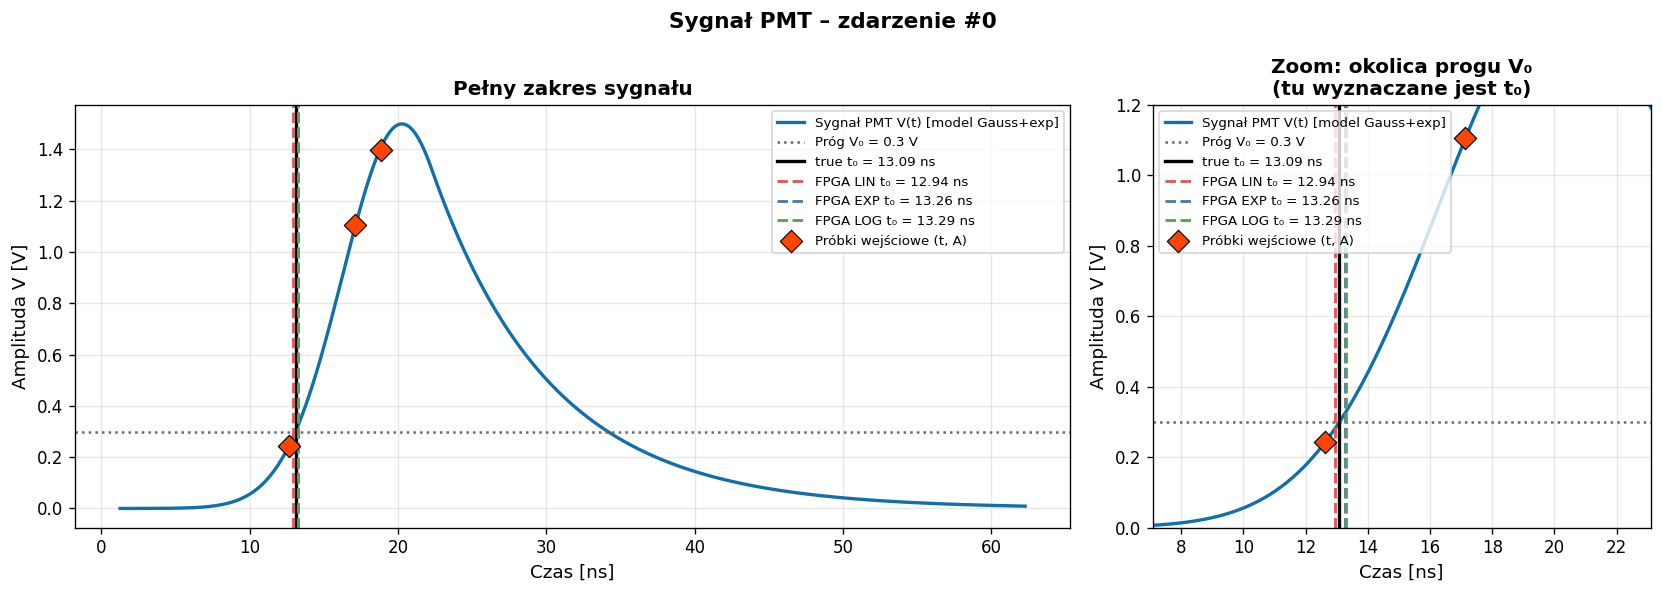

In [ ]:
EVENT_IDX = 0   # zmień aby obejrzeć inne zdarzenie
row_v = df.iloc[EVENT_IDX]

sigma  = row_v['sigma_ns']
tau    = row_v['tau_ns']
t_peak = row_v['true_t0']
Amax   = row_v['true_amax']
t_true = row_v['true_t_leading']

t_match = t_peak + sigma**2 / tau
C_norm  = np.exp(-0.5 * (sigma / tau)**2)
t_arr   = np.linspace(t_peak - 4*sigma - 3, t_peak + 4*tau + 10, 700)
V = np.where(t_arr <= t_match,
             Amax * np.exp(-0.5*((t_arr - t_peak)/sigma)**2),
             Amax * C_norm * np.exp(-(t_arr - t_match)/tau))

# Wyniki t0 z FPGA dla tego zdarzenia
t0_fpga = {}
for mode in MODES:
    mn  = MODE_NAMES[mode]
    sub = res[(res['event_id'] == int(row_v['event_id'])) & (res['mode'] == mn)]
    if not sub.empty:
        t0_fpga[mn] = sub.iloc[0]['fpga_t0']

fig, (ax_main, ax_zoom) = plt.subplots(
    1, 2, figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle(f'Sygnał PMT – zdarzenie #{int(row_v["event_id"])}  |  ',
             fontsize=13, fontweight='bold')

for ax in [ax_main, ax_zoom]:
    ax.plot(t_arr, V, color='#1170AA', lw=2,
            label='Sygnał PMT  V(t)  [model Gauss+exp]')
    ax.axhline(THRESHOLD, color='dimgray', ls=':', lw=1.5,
               label=f'Próg V₀ = {THRESHOLD} V')
    ax.axvline(t_true, color='black', lw=2.0, ls='-',
               label=f'true t₀ = {t_true:.2f} ns  (referencja)')
    for mn, t0v in t0_fpga.items():
        if t0v is not None and not np.isnan(t0v):
            ax.axvline(t0v, color=COLORS[mn], lw=1.7, ls='--',
                       label=f'FPGA {mn} t₀ = {t0v:.2f} ns')
    ax.scatter([row_v['t1'], row_v['t2'], row_v['t3']],
               [row_v['A1'], row_v['A2'], row_v['A3']],
               s=90, zorder=6, color='orangered', marker='D',
               edgecolors='black', lw=0.7,
               label='Próbki wejściowe (t, A)')
    ax.set_ylabel('Amplituda  V  [V]', fontsize=11)
    ax.grid(True, alpha=0.3)

ax_main.set_xlabel('Czas  [ns]', fontsize=11)
ax_main.set_title('Pełny zakres sygnału', fontsize=11)
ax_main.legend(fontsize=8, loc='upper right')

margin = 6
ax_zoom.set_xlim(t_true - margin, t_true + margin + 4)
ax_zoom.set_ylim(0, THRESHOLD * 4)
ax_zoom.set_xlabel('Czas  [ns]', fontsize=11)
ax_zoom.set_title('Zoom: okolica progu V₀\n(tu wyznaczane jest t₀)', fontsize=11)
ax_zoom.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('plot5_pmt_pulse.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Pomiar wydajności: ARM (Python) vs FPGA (koprocesor)

In [ ]:
N_BENCH = 200
row_b   = df.iloc[0]
t1b, a1b = row_b['t1'], row_b['A1']
t2b, a2b = row_b['t2'], row_b['A2']
t3b, a3b = row_b['t3'], row_b['A3']

# ARM – 3 funkcje Python
t0 = time.perf_counter()
for _ in range(N_BENCH):
    py_linear(t1b, a1b, t2b, a2b, THRESHOLD)
    py_exponential(t1b, a1b, t2b, a2b, THRESHOLD)
    py_logarithmic(t1b, a1b, t2b, a2b, t3b, a3b, THRESHOLD)
arm_us = (time.perf_counter() - t0) / N_BENCH * 1e6

# FPGA – 3 tryby (z overhead AXI-Lite)
t0 = time.perf_counter()
for _ in range(N_BENCH):
    for m in MODES:
        fpga_compute(t1b, a1b, t2b, a2b, t3b, a3b, THRESHOLD, m)
fpga_us = (time.perf_counter() - t0) / N_BENCH * 1e6

print(f'N_BENCH = {N_BENCH}')
print(f'ARM  Python   (3 metody):  {arm_us:.2f} µs / zdarzenie')
print(f'FPGA koprocesor (3 tryby): {fpga_us:.2f} µs / zdarzenie  (w tym overhead AXI)')
print(f'Przyspieszenie:            {arm_us/fpga_us:.2f}×')

N_BENCH = 200
ARM Python (3 metody):          119.80 µs / zdarzenie
FPGA AXI-Lite (3 tryby):        281.60 µs / zdarzenie
Relacja ARM/FPGA:               0.43×


### 12.1 Wykres wydajności: ARM vs FPGA

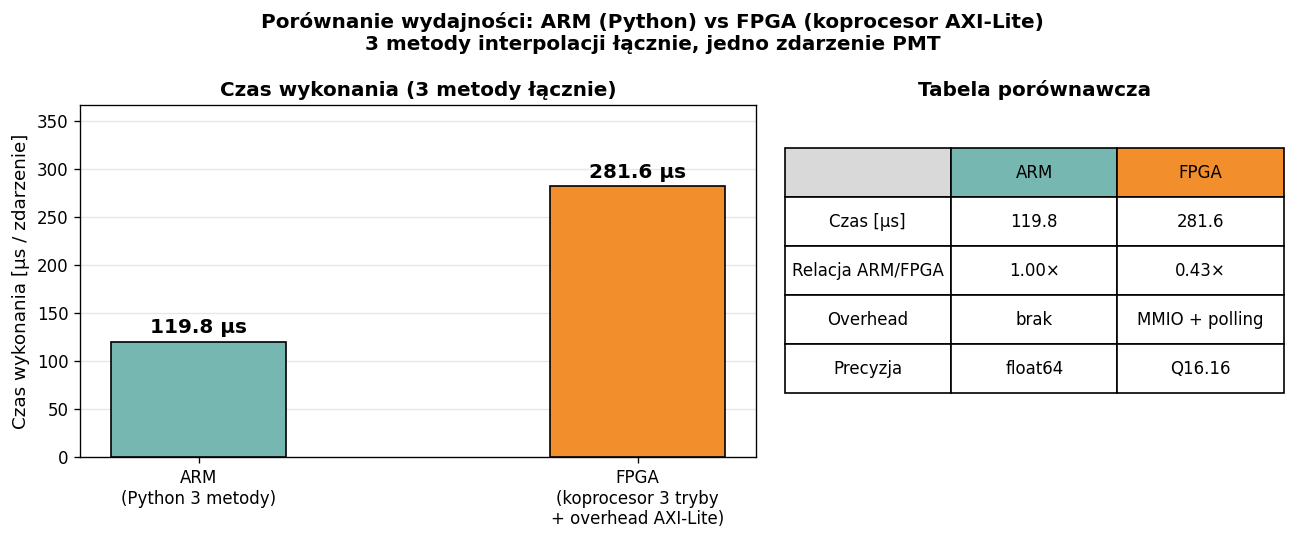

In [ ]:
fig, (ax_bar, ax_txt) = plt.subplots(
    1, 2, figsize=(11, 4.5),
    gridspec_kw={'width_ratios': [1.3, 1]})
fig.suptitle('Porównanie wydajności: ARM (Python) vs FPGA (koprocesor AXI-Lite)\n'
             '3 metody interpolacji łącznie, jedno zdarzenie PMT',
             fontsize=12, fontweight='bold')

labels = ['ARM\n(Python 3 metody)', 'FPGA\n(koprocesor 3 tryby\n+ overhead AXI-Lite)']
vals   = [arm_us, fpga_us]
clrs   = ['#76b7b2', '#f28e2b']

bars = ax_bar.bar(labels, vals, color=clrs, edgecolor='black', width=0.4, zorder=3)
for bar, v in zip(bars, vals):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{v:.1f} µs', ha='center', va='bottom',
                fontsize=12, fontweight='bold')
ax_bar.set_ylabel('Czas wykonania  [µs / zdarzenie]', fontsize=11)
ax_bar.set_ylim(0, max(vals) * 1.30)
ax_bar.set_title('Czas wykonania (3 metody łącznie)', fontsize=11)
ax_bar.grid(True, axis='y', alpha=0.3, zorder=0)

ax_txt.axis('off')
info = [['',           'ARM',          'FPGA'],
        ['Czas [µs]',  f'{arm_us:.1f}', f'{fpga_us:.1f}'],
        ['Przyspieszenie', '1.00×',     f'{arm_us/fpga_us:.2f}×'],
        ['Overhead',   'brak',          'AXI polling'],
        ['Precyzja',   'float64',       'Q16.16 fixed-pt'],]
tbl = ax_txt.table(cellText=info[1:], colLabels=info[0],
                   cellLoc='center', loc='center',
                   bbox=[0.02, 0.18, 0.96, 0.70])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl[0,0].set_facecolor('#d9d9d9')
tbl[0,1].set_facecolor('#76b7b2')
tbl[0,2].set_facecolor('#f28e2b')
ax_txt.set_title('Tabela porównawcza', fontsize=11)

plt.tight_layout()
plt.savefig('plot6_performance.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Zapis wyników do CSV

In [ ]:
out_file = 'wyniki_fpga.csv'
res.to_csv(out_file, index=False, float_format='%.6f')
print(f'Zapisano: {out_file}  ({len(res)} wierszy)')
res.head(6)

Zapisano: wyniki_fpga.csv (60 wierszy)


,event_id,mode,fpga_t0,python_t0,true_t0,err_vs_python,err_vs_true,overflow
0,0,LIN,12.9392,12.9387,13.0911,0.0005,0.1519,False
1,0,EXP,13.2637,13.2697,13.0911,0.0060,0.1726,False
2,0,LOG,13.2857,13.2697,13.0911,0.0160,0.1946,False
3,1,LIN,14.6880,14.6870,14.6559,0.0010,0.0321,False
4,1,EXP,14.6290,14.6210,14.6559,0.0080,0.0269,False
5,1,LOG,14.6058,14.6210,14.6559,0.0152,0.0501,False


---
## Podsumowanie wyników

| Metoda | Błąd model FPGA vs Python (mean) | Błąd model FPGA vs true t₀ (mean) | Uwagi |
|--------|------------------------------------|----------------------------------|-------|
| LIN | 0.0006 ns | 0.5209 ns | Zgodność z golden modelem ograniczona głównie przez kwantyzację i dzielenie FXP |
| EXP | 0.0061 ns | 0.5134 ns | Najmniejszy średni błąd względem `true_t0` w tym zbiorze |
| LOG | 0.0120 ns | 0.5315 ns | Nieco większy błąd aproksymacji logarytmu, nadal blisko golden modelu |

### Wnioski

1. Wszystkie trzy tryby modelu sprzętowego pozostają blisko wyników funkcji referencyjnych Python; nie występują nierealistyczne wartości wielotysięczne dla LIN.
2. Różnice względem `true_t0` są znacznie większe niż różnice FPGA–Python, co wskazuje, że dominującym źródłem błędu jest metoda rekonstrukcji i położenie próbek, a nie sama arytmetyka Q16.16.
3. W wariancie AXI-Lite czas wywołania jest zdominowany przez MMIO i polling.
4. Rozdzielczość pojedynczego kroku Q16.16 wynosi około 0.0000153 ns; większe odchylenia mogą wynikać z kolejności operacji, obcięć pośrednich oraz aproksymacji funkcji nieliniowych.
